# Layer 1: Structured Alt Data

## Introduction

Layer 0 showed that a random walk naive forecast and a SARIMA model
landed within a few tenths of a percentage point of each other on MAPE,
both around 3%. This notebook asks whether adding structured alt data buys anything against that bar, following the nowcasting
approach in Jaax et al., 2024: combine high-frequency market data and
search interest with the target series, then feed it to a model that can
be inspected rather than trusted blindly.

Features, see `src/features.py` for exact sourcing:
- USD/KRW and WTI oil from FRED, daily, resampled to monthly mean
- SOX index, Samsung Electronics, and SK Hynix from Yahoo Finance, monthly
- BDRY ETF as a Baltic Dry Index proxy from Yahoo Finance. The real BDI
  isn't published anywhere free, so this is a
  market-priced stand-in, named as a substitution and not treated as the
  genuine article.
- Google Trends search interest, via `pytrends`
- Target lag-1 and lag-12, the series' own recent history, since Layer 0
  already showed the autoregressive component is hard to beat

Not included yet: Korea Customs first-10 and first-20-day flash export
figures. Probably the best feature for this task, but the API
needs a manual account registration at data.go.kr that can't be done. Stubbed in `src/customs_flash.py` for a possible future extension.


In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import shap

from layer1_model import build_dataset, make_gbm_forecaster, make_ridge_forecaster, fit_full_model
from walk_forward import walk_forward_x, rmse, mape

plt.rcParams["figure.figsize"] = (11, 4)

C:\qrvenv_work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Methodology

Timing and look-ahead: all features for month t are built only from data
observable by the end of month t. Market prices, FX, and search interest
are all available same day, so this is a legitimate nowcast of month t's
export figure, which is only published after month t ends. Additionally,
`target_lag1` and `target_lag12` only use past export values.

Sample constraint of BDRY, the Baltic Dry proxy, only starts trading in
March 2018, which caps the whole feature matrix at 98 monthly rows, far
less than Layer 0's 436.

Two models, a GBM, `HistGradientBoostingRegressor`, shallow
at depth 3 with 7 leaves, and a heavily regularized Ridge regression on
the same features. Running both isolates why a result lands where it
does. Is it that the alt data lacks signal, or that a flexible model is
the wrong amount of complexity for around 90 training rows? This is the
same question the project's capstone surface asks, about RMSE against
feature count and regularization, answered once here in miniature first.

Validation: same rolling-origin walk-forward as Layer 0, 36 origins, one
month ahead, refit at every origin.

A note on lightgbm: the original plan was LightGBM, but the installed
build segfaults intermittently on repeated `.fit()` calls in this Windows
environment. This is reproducible and a native-library issue, not a data
problem. Switched to sklearn's `HistGradientBoostingRegressor`, which ran
all 36 fits clean. Worth retrying lightgbm on Linux if training speed
becomes a bottleneck later.

In [2]:
y, X = build_dataset()
print(f"{len(y)} rows, {X.shape[1]} features, {y.index.min().date()} to {y.index.max().date()}")
X.head()

98 rows, 9 features, 2018-03-01 to 2026-04-01


,usd_krw,oil_wti,sox,samsung,skhynix,bdry,trends,target_lag1,target_lag12
date,,,,,,,,,
2018-03-01,1069.941818,62.724762,1328.900024,53000.0,84500.0,23.4405,0.0,5.024981e+10,4.783716e+10
2018-04-01,1068.045238,66.253810,1244.400024,50700.0,93400.0,21.8564,0.0,4.900813e+10,4.886361e+10
2018-05-01,1076.659545,69.978182,1379.000000,46650.0,85700.0,21.3125,0.0,4.933546e+10,4.621146e+10
2018-06-01,1094.355238,67.873333,1313.699951,46250.0,86300.0,21.9150,0.0,5.105098e+10,4.949669e+10
2018-07-01,1122.202857,70.981429,1367.469971,48450.0,83000.0,23.9606,0.0,5.011057e+10,4.807330e+10


In [3]:
N_TEST = 36

models = {
    "gbm": make_gbm_forecaster(),
    "ridge": make_ridge_forecaster(alpha=10.0),
}

results = {name: walk_forward_x(y, X, fn, n_test=N_TEST) for name, fn in models.items()}

for name, df in results.items():
    print(f"{name:>10}  RMSE={rmse(df):>14,.0f}  MAPE={mape(df):>6.2f}%")

print()
print("Layer 0 reference (same 36-month window, full 436-obs history):")
print(f"{'naive':>10}  RMSE={2_847_251_652:>14,.0f}  MAPE={3.14:>6.2f}%")
print(f"{'sarima':>10}  RMSE={2_881_346_571:>14,.0f}  MAPE={2.92:>6.2f}%")

       gbm  RMSE= 4,661,166,131  MAPE=  4.92%
     ridge  RMSE= 3,281,969,926  MAPE=  3.30%

Layer 0 reference (same 36-month window, full 436-obs history):
     naive  RMSE= 2,847,251,652  MAPE=  3.14%
    sarima  RMSE= 2,881,346,571  MAPE=  2.92%


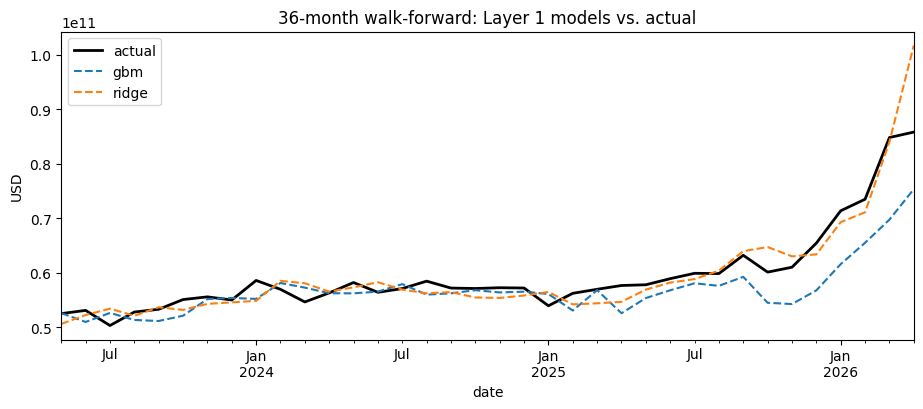

In [4]:
fig, ax = plt.subplots()
results["gbm"]["actual"].plot(ax=ax, label="actual", color="black", linewidth=2)
for name in models:
    results[name]["forecast"].plot(ax=ax, label=name, linestyle="--")
ax.set_title("36-month walk-forward: Layer 1 models vs. actual")
ax.set_ylabel("USD")
ax.legend()
plt.show()

## Interpretability: SHAP on the GBM

Fit once on the full sample rather than per walk-forward origin. The
walk-forward runs are for scoring; this pass is for explaining what the
model leans on.

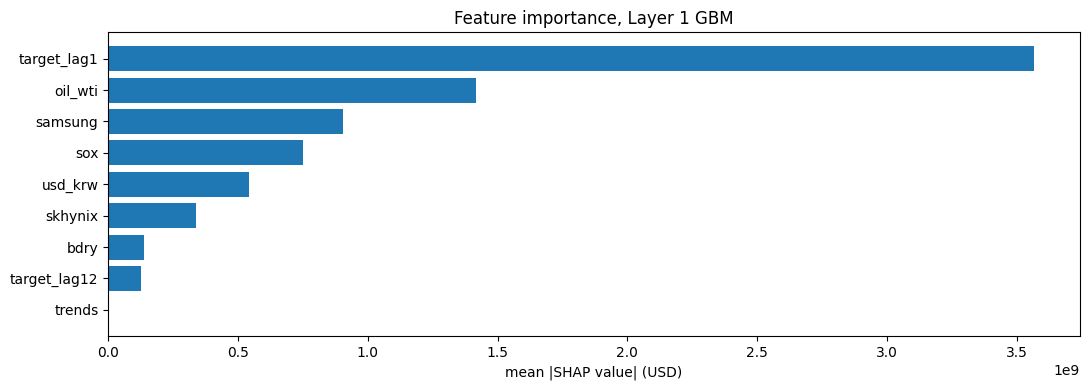

In [5]:
model = fit_full_model(y, X)
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

mean_abs = np.abs(shap_values.values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]

fig, ax = plt.subplots()
ax.barh([X.columns[i] for i in order][::-1], mean_abs[order][::-1])
ax.set_xlabel("mean |SHAP value| (USD)")
ax.set_title("Feature importance, Layer 1 GBM")
plt.tight_layout()
plt.show()

## Findings

Neither Layer 1 model beats Layer 0 on this window. GBM lands at RMSE
4.66B and MAPE 4.92%, clearly worse than naive or SARIMA. Ridge lands at
RMSE 3.28B and MAPE 3.30%, closer but still not an improvement.

The gap between GBM and Ridge is worth exploring. Same features, same
walk-forward setup, and the only difference is model flexibility. Ridge
closes most of the distance to the baseline while GBM does not. With around
90 training rows and 9 features, a tree model with enough flexibility to
split on interactions overfits the training window before it ever gets
to the test origin. 

SHAP confirms the autoregressive term dominates. `target_lag1` carries
roughly two to three times the importance of any single alt data
feature. That is consistent with Layer 0's finding that a plain random
walk is already a good benchmark. Most of the exploitable signal at h=1
is already in the series' own recent history.

Google Trends contributed nothing, a SHAP importance of exactly zero,
meaning the GBM never split on it. Either the keyword choice was wrong,
the signal is too noisy at monthly aggregation, or search interest does not lead Korean exports the way it leads other series in
the literature. Worth trying a different keyword or a lag before
concluding it is useless for future extension.

## Key takeaways

Layer 1 does not yet earn its complexity. The bottleneck looks like sample size more than feature relevance. The
BDRY-driven 98-row cap is doing a lot of the damage. Two concrete next
steps stand out. First, source the Korea Customs flash export figures and
add the single feature most likely to move this, since it is a leading indicator rather than a coincident one like the rest of this
layer - notebook 05 does exactly this. Second, consider dropping BDRY to recover the
longer 2015 to 2026 window that all other features support, and see if
more data alone closes the gap before adding anything else.